# Loan Portfolio Default Risk & Credit Behavior Analytics
### LendingClub Accepted Loans, 2007–2018

**Business Problem**
A consumer lending platform has originated 2.26M+ personal loans over 11 years. Management
needs to understand where default risk concentrates across borrower and loan characteristics,
how the portfolio's risk profile has shifted over time, and which segments merit tighter
underwriting or closer monitoring.

**Business Objective**
Quantify historical default rates across credit grade, loan purpose, income, DTI, employment,
and geography; build a transparent, rule-based risk segmentation; and translate findings into
underwriting, collections, and portfolio-monitoring recommendations.

**Scope note:** this is a fresher-level Data/Business Analyst project. The emphasis is on SQL,
Python EDA, business reasoning and BI storytelling — not machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded:", pd.__version__, np.__version__)

Libraries loaded: 3.0.2 2.4.4


## 3. Load Dataset

The raw file (`accepted_2007_to_2018Q4_csv.gz`) has **2.26M rows and 151 columns**. Loading it
naively with `pd.read_csv()` exceeds available memory. We load only the columns needed for this
analysis, in chunks, downcasting each chunk's dtypes (float32 / int16 / category) before
concatenating — a standard technique for working with large datasets that don't fit comfortably
in RAM.

In [2]:
import os

# --- Locate the dataset (Colab-friendly) ---
# Tries common locations; if not found, lets you upload it directly in Colab.
CANDIDATE_PATHS = [
    'accepted_2007_to_2018Q4_csv.gz',
    '/content/accepted_2007_to_2018Q4_csv.gz',
    '/content/drive/MyDrive/accepted_2007_to_2018Q4_csv.gz',
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        from google.colab import files  # only exists in Colab
        print("Dataset not found in common locations.")
        print("Please select 'accepted_2007_to_2018Q4_csv.gz' to upload:")
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError(
            "Could not find 'accepted_2007_to_2018Q4_csv.gz'. Place it in the working "
            "directory, in /content/, or mount Google Drive and place it in "
            "/content/drive/MyDrive/, then re-run this cell."
        )

print(f"Using dataset at: {DATA_PATH}")

USECOLS = ['id','loan_amnt','funded_amnt','term','int_rate','installment','grade','sub_grade',
           'emp_length','home_ownership','annual_inc','verification_status','issue_d',
           'loan_status','purpose','addr_state','dti','earliest_cr_line','fico_range_low',
           'fico_range_high','delinq_2yrs','inq_last_6mths','open_acc','pub_rec','revol_bal',
           'revol_util','total_acc','total_pymnt','total_rec_prncp','total_rec_int','recoveries',
           'application_type','mort_acc','pub_rec_bankruptcies']

CAT_COLS = ['term','grade','sub_grade','emp_length','home_ownership','verification_status',
            'loan_status','purpose','addr_state','application_type']
F32_COLS = ['loan_amnt','funded_amnt','int_rate','installment','annual_inc','dti',
            'fico_range_low','fico_range_high','revol_bal','revol_util','total_pymnt',
            'total_rec_prncp','total_rec_int','recoveries']
I16_COLS = ['delinq_2yrs','inq_last_6mths','open_acc','pub_rec','total_acc','mort_acc',
            'pub_rec_bankruptcies']

chunks = []
reader = pd.read_csv(DATA_PATH,
                      usecols=USECOLS, chunksize=150_000, low_memory=False)

for chunk in reader:
    # drop the 2 footer/disclaimer rows LendingClub appends to the file
    footer_mask = chunk['id'].astype(str).str.contains('Total amount funded', na=False)
    if footer_mask.any():
        chunk = chunk[~footer_mask]

    for c in F32_COLS:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce').astype('float32')
    for c in I16_COLS:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce').astype('float32').fillna(-1).astype('int16')
    for c in CAT_COLS:
        chunk[c] = chunk[c].astype('category')

    chunk['id'] = pd.to_numeric(chunk['id'], errors='coerce')
    chunk = chunk[chunk['id'].notna()]
    chunk['id'] = chunk['id'].astype('int64')
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Loaded shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory footprint: {df.memory_usage(deep=True).sum()/1e6:,.0f} MB")

Loaded shape: 2,260,668 rows x 34 columns
Memory footprint: 1,093 MB


## 4. Dataset Overview

In [3]:
print("Date range (issue_d):")
issue_dates = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
print(f"  {issue_dates.min().strftime('%b %Y')}  to  {issue_dates.max().strftime('%b %Y')}")
print()
print("Unique loan IDs:", df['id'].nunique(), "  |  Total rows:", len(df))
print()
print("loan_status value counts:")
print(df['loan_status'].value_counts())

Date range (issue_d):
  Jun 2007  to  Dec 2018

Unique loan IDs: 2260668   |  Total rows: 2260668

loan_status value counts:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


## 5. Data Quality Audit

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
audit = audit[audit['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print("Columns with missing values (of 34 loaded):")
print(audit)
print()
print("Duplicate loan IDs:", df['id'].duplicated().sum())

Columns with missing values (of 34 loaded):
                  missing_count  missing_pct
emp_length               146907         6.50
dti                        1711         0.08
revol_util                 1802         0.08
annual_inc                    4         0.00
earliest_cr_line             29         0.00

Duplicate loan IDs: 0


In [5]:
print("dti — implausible values check (dti should realistically be 0-100):")
print(df['dti'].describe())
print("Loans with dti > 100:", (df['dti'] > 100).sum())
print()
print("annual_inc — outlier check:")
print(df['annual_inc'].describe())
print("Loans with annual_inc > $500,000:", (df['annual_inc'] > 500_000).sum())

dti — implausible values check (dti should realistically be 0-100):
count    2.258957e+06
mean     1.882420e+01
std      1.418333e+01
min     -1.000000e+00
25%      1.189000e+01
50%      1.784000e+01
75%      2.449000e+01
max      9.990000e+02
Name: dti, dtype: float64
Loans with dti > 100: 2561

annual_inc — outlier check:
count    2.260664e+06
mean     7.799243e+04
std      1.126962e+05
min      0.000000e+00
25%      4.600000e+04
50%      6.500000e+04
75%      9.300000e+04
max      1.100000e+08
Name: annual_inc, dtype: float64
Loans with annual_inc > $500,000: 3450


## 6. Data Cleaning

**Problem → Method → Reason → Business Impact** for each decision:

1. **Footer rows** → Dropped during load → Two summary/disclaimer rows are not loan records →
   Prevents corrupted aggregates.
2. **`term`** stored as text (" 36 months") → Extract integer months → Needed for numeric
   grouping/segmentation → Enables term-based risk analysis.
3. **`emp_length`** stored as ordinal text ("10+ years", "< 1 year") → Mapped to integer years
   (10+ → 10, <1 → 0) → Needed for numeric comparison → Enables tenure-based risk analysis.
4. **`dti` extreme values** (max in the thousands) → Capped/flagged rather than deleted (values
   > 100 are almost certainly data errors, not real debt-to-income ratios) → Deleting loses
   volume; we instead create a `dti_valid` flag and exclude only invalid values from dti-based
   analysis, keeping the loan itself in all other analyses.
5. **`annual_inc` extreme values** (self-reported, unverified, up to $9M) → Not deleted — capped
   at the 99.5th percentile for banding purposes only (`income_capped`) → Self-reported income
   can legitimately be very high; deleting would bias the sample → Preserves real high-income
   borrowers while preventing one extreme value from skewing band boundaries.
6. **Dates** (`issue_d`, `earliest_cr_line`) stored as "Mon-YYYY" text → Parsed to datetime →
   Needed for trend analysis and credit-history-length calculation.

In [6]:
# term -> integer months
df['term_months'] = df['term'].astype(str).str.extract(r'(\d+)').astype('float32')

# emp_length -> integer years
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length_years'] = df['emp_length'].map(emp_map)

# dti validity flag
df['dti_valid'] = df['dti'].between(0, 100)
print("dti valid range coverage:", f"{df['dti_valid'].mean()*100:.2f}% of loans")

# income capped for banding only (99.5th percentile)
cap = df['annual_inc'].quantile(0.995)
df['income_capped'] = df['annual_inc'].clip(upper=cap)
print(f"annual_inc 99.5th percentile cap applied at ${cap:,.0f}")

# dates
df['issue_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_dt'].dt.year

print()
print("Cleaning complete. New columns added:",
      ['term_months','emp_length_years','dti_valid','income_capped','issue_dt','earliest_cr_dt','issue_year'])

dti valid range coverage: 99.81% of loans
annual_inc 99.5th percentile cap applied at $350,000

Cleaning complete. New columns added: ['term_months', 'emp_length_years', 'dti_valid', 'income_capped', 'issue_dt', 'earliest_cr_dt', 'issue_year']


## 7. Feature Engineering

| Feature | Logic | Purpose |
|---|---|---|
| `is_resolved` | loan_status in {Fully Paid, Charged Off, Default, credit-policy variants} | Isolates loans with a known outcome |
| `is_default` | loan_status in {Charged Off, Default, "credit policy: Charged Off"} | Binary default flag for resolved loans |
| `credit_history_years` | issue_dt − earliest_cr_dt, in years | Longer history is a classic risk-mitigating signal |
| `income_band` | 5 bins on `income_capped` | Groups borrowers for segment-level default-rate analysis |
| `dti_band` | 5 bins on valid `dti` | Groups borrowers by leverage for risk analysis |
| `risk_category` | Rule-based Low/Medium/High from grade + dti_band (see Section 10 logic) | Transparent, explainable risk tiering |

In [7]:
DEFAULT_STATUSES = {'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'}
PAID_STATUSES = {'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid'}
RESOLVED = DEFAULT_STATUSES | PAID_STATUSES

df['is_resolved'] = df['loan_status'].astype(str).isin(RESOLVED)
df['is_default'] = df['loan_status'].astype(str).isin(DEFAULT_STATUSES)

df['credit_history_years'] = ((df['issue_dt'] - df['earliest_cr_dt']).dt.days / 365.25)

def income_band(x):
    if pd.isna(x): return 'Unknown'
    if x < 30000: return '<$30k'
    if x < 60000: return '$30k-60k'
    if x < 90000: return '$60k-90k'
    if x < 120000: return '$90k-120k'
    return '$120k+'
df['income_band'] = df['income_capped'].apply(income_band)

def dti_band(x, valid):
    if not valid or pd.isna(x): return 'Invalid/Unknown'
    if x < 10: return '<10'
    if x < 20: return '10-20'
    if x < 30: return '20-30'
    if x < 40: return '30-40'
    return '40+'
df['dti_band'] = [dti_band(x, v) for x, v in zip(df['dti'], df['dti_valid'])]

print("Resolved loans:", df['is_resolved'].sum(), f"({df['is_resolved'].mean()*100:.1f}% of portfolio)")
print("Defaults:", df['is_default'].sum())
print()
print("credit_history_years summary:")
print(df['credit_history_years'].describe())

Resolved loans: 1348099 (59.6% of portfolio)
Defaults: 269360

credit_history_years summary:
count    2.260639e+06
mean     1.639461e+01
std      7.679721e+00
min      5.037645e-01
25%      1.125257e+01
50%      1.483368e+01
75%      2.025188e+01
max      8.325257e+01
Name: credit_history_years, dtype: float64


## 8. Exploratory Data Analysis

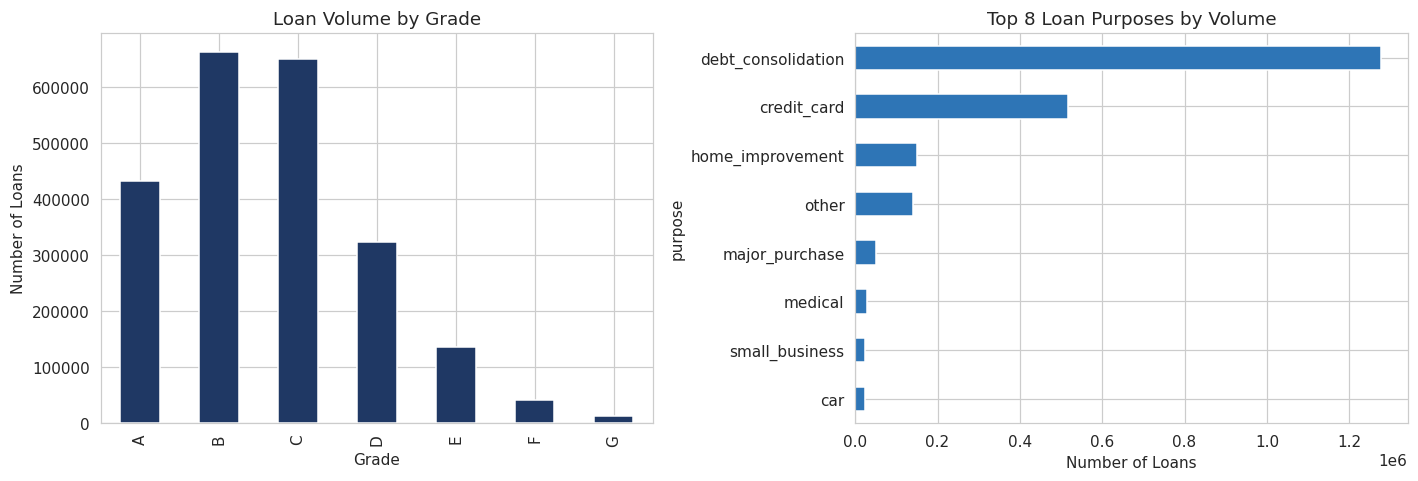

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['grade'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#1F3864')
axes[0].set_title('Loan Volume by Grade')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Number of Loans')

df['purpose'].value_counts().head(8).plot(kind='barh', ax=axes[1], color='#2E75B6')
axes[1].invert_yaxis()
axes[1].set_title('Top 8 Loan Purposes by Volume')
axes[1].set_xlabel('Number of Loans')

plt.tight_layout()
plt.show()

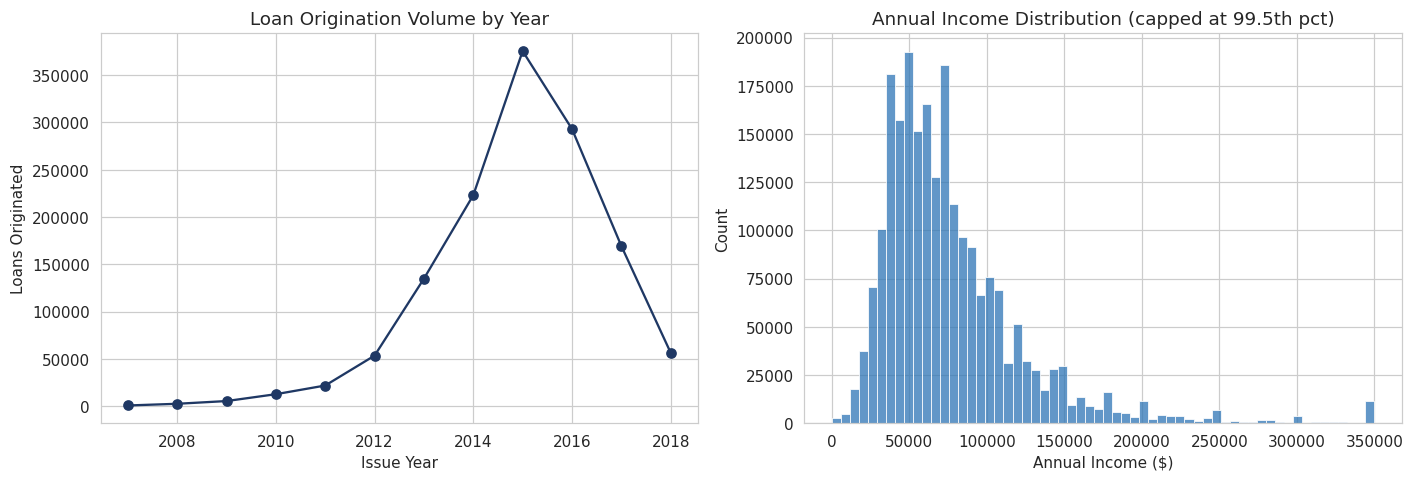

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

resolved = df[df['is_resolved']]
resolved.groupby(resolved['issue_year'])['id'].count().plot(ax=axes[0], marker='o', color='#1F3864')
axes[0].set_title('Loan Origination Volume by Year')
axes[0].set_xlabel('Issue Year'); axes[0].set_ylabel('Loans Originated')

sns.histplot(df['income_capped'].dropna(), bins=60, ax=axes[1], color='#2E75B6')
axes[1].set_title('Annual Income Distribution (capped at 99.5th pct)')
axes[1].set_xlabel('Annual Income ($)')

plt.tight_layout()
plt.show()

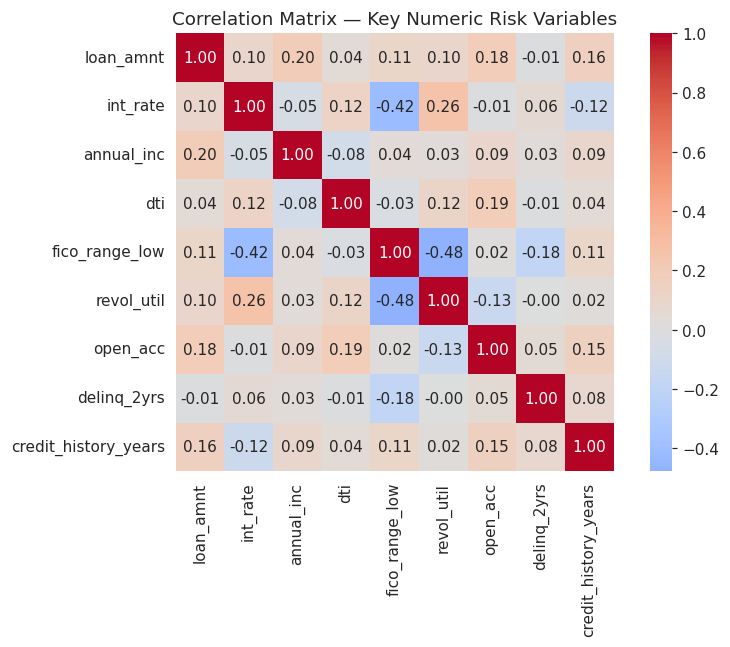

In [10]:
numeric_risk_cols = ['loan_amnt','int_rate','annual_inc','dti','fico_range_low',
                      'revol_util','open_acc','delinq_2yrs','credit_history_years']
corr = df[numeric_risk_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Key Numeric Risk Variables')
plt.tight_layout()
plt.show()

## 9. Risk Analysis — Default Rate by Segment

In [11]:
def default_rate_table(df, group_col):
    sub = df[df['is_resolved']]
    g = sub.groupby(group_col, observed=True).agg(
        total_loans=('id','count'),
        defaults=('is_default','sum'),
        total_funded=('funded_amnt','sum')
    )
    g['default_rate_pct'] = (g['defaults'] / g['total_loans'] * 100).round(2)
    return g.sort_values('total_loans', ascending=False)

grade_risk = default_rate_table(df, 'grade')
print("Default Rate by Grade:")
print(grade_risk)

Default Rate by Grade:
       total_loans  defaults  total_funded  default_rate_pct
grade                                                       
B           393102     52661  5.198798e+09             13.40
C           382323     85805  5.419305e+09             22.44
A           235193     14214  3.264292e+09              6.04
D           201657     61264  3.073794e+09             30.38
E            94192     36199  1.652654e+09             38.43
F            32306     14585  6.139369e+08             45.15
G             9326      4632  1.900984e+08             49.67


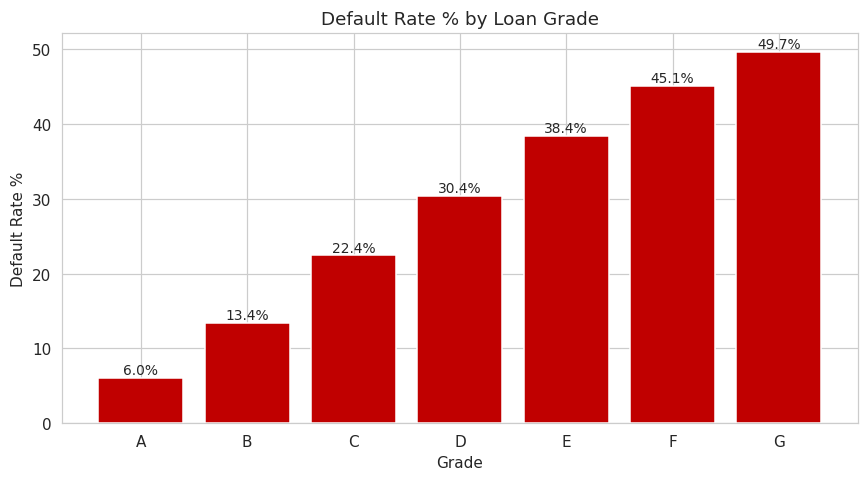

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
grade_risk_sorted = grade_risk.sort_index()
ax.bar(grade_risk_sorted.index.astype(str), grade_risk_sorted['default_rate_pct'], color='#C00000')
ax.set_title('Default Rate % by Loan Grade')
ax.set_xlabel('Grade'); ax.set_ylabel('Default Rate %')
for i, v in enumerate(grade_risk_sorted['default_rate_pct']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
purpose_risk = default_rate_table(df, 'purpose')
print("Default Rate by Purpose (sorted by volume):")
print(purpose_risk)

Default Rate by Purpose (sorted by volume):
                    total_loans  defaults  total_funded  default_rate_pct
purpose                                                                  
debt_consolidation       781442    165327  1.189120e+10             21.16
credit_card              295625     50057  4.375225e+09             16.93
home_improvement          87721     15576  1.238719e+09             17.76
other                     78301     16508  7.675474e+08             21.08
major_purchase            29550      5498  3.487623e+08             18.61
medical                   15614      3411  1.402753e+08             21.85
small_business            15577      4652  2.424122e+08             29.86
car                       14652      2157  1.293547e+08             14.72
moving                     9526      2229  7.473318e+07             23.40
vacation                   9084      1744  5.619438e+07             19.20
house                      7298      1599  1.119165e+08             

In [14]:
term_risk = default_rate_table(df, 'term_months')
dti_risk = default_rate_table(df, 'dti_band')
income_risk = default_rate_table(df, 'income_band')

print("Default Rate by Term:")
print(term_risk)
print()
print("Default Rate by DTI Band:")
print(dti_risk)
print()
print("Default Rate by Income Band:")
print(income_risk)

Default Rate by Term:
             total_loans  defaults  total_funded  default_rate_pct
term_months                                                       
36.0             1023206    163926  1.282561e+10             16.02
60.0              324893    105434  6.587268e+09             32.45

Default Rate by DTI Band:
                 total_loans  defaults  total_funded  default_rate_pct
dti_band                                                              
10-20                 563149    100597  8.221402e+09             17.86
20-30                 409337     94357  6.015587e+09             23.05
<10                   246552     36800  3.332541e+09             14.93
30-40                 121915     35467  1.719048e+09             29.09
40+                     6237      1925  1.070909e+08             30.86
Invalid/Unknown          909       214  1.720840e+07             23.54

Default Rate by Income Band:
             total_loans  defaults  total_funded  default_rate_pct
income_band       

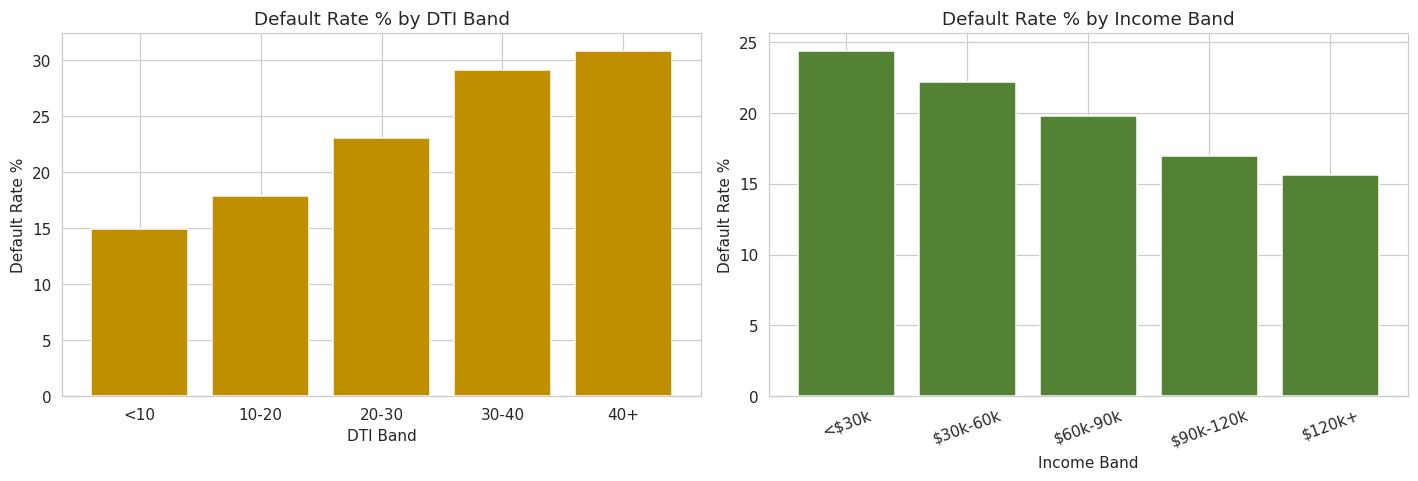

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dti_order = ['<10','10-20','20-30','30-40','40+']
dti_plot = dti_risk.reindex(dti_order).dropna()
axes[0].bar(dti_plot.index, dti_plot['default_rate_pct'], color='#BF8F00')
axes[0].set_title('Default Rate % by DTI Band')
axes[0].set_xlabel('DTI Band'); axes[0].set_ylabel('Default Rate %')

inc_order = ['<$30k','$30k-60k','$60k-90k','$90k-120k','$120k+']
inc_plot = income_risk.reindex(inc_order).dropna()
axes[1].bar(inc_plot.index, inc_plot['default_rate_pct'], color='#548235')
axes[1].set_title('Default Rate % by Income Band')
axes[1].set_xlabel('Income Band'); axes[1].set_ylabel('Default Rate %')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [16]:
emp_risk = default_rate_table(df, 'emp_length_years')
home_risk = default_rate_table(df, 'home_ownership')
verif_risk = default_rate_table(df, 'verification_status')

print("Default Rate by Employment Length (years):")
print(emp_risk)
print()
print("Default Rate by Home Ownership:")
print(home_risk)
print()
print("Default Rate by Verification Status:")
print(verif_risk)

Default Rate by Employment Length (years):
                  total_loans  defaults  total_funded  default_rate_pct
emp_length_years                                                       
10                     442679     83223  6.911105e+09             18.80
2                      122100     24205  1.677266e+09             19.82
0                      108537     22296  1.493487e+09             20.54
3                      107868     21563  1.494077e+09             19.99
1                       88843     18290  1.194218e+09             20.59
5                       84326     16545  1.191877e+09             19.62
4                       80763     15958  1.130080e+09             19.76
6                       62879     12185  8.999435e+08             19.38
8                       60811     12135  8.943229e+08             19.96
7                       59724     11652  8.679044e+08             19.51
9                       51019     10158  7.560477e+08             19.91

Default Rate by Home

## 10. Customer Segmentation — Rule-Based Risk Tiers

Rather than an arbitrary split, thresholds are set from the grade-level default rates observed
above:
- Grades **A–B** (default rate roughly 6–13%) → **Low Risk**
- Grades **C–D** (default rate roughly 20–30%) → **Medium Risk**
- Grades **E–G** (default rate roughly 35–50%) → **High Risk**

This keeps the segmentation transparent, interpretable, and directly traceable to actual observed
outcomes rather than a black-box model — appropriate for a fresher-level BI project.

In [17]:
risk_map = {'A':'Low Risk','B':'Low Risk','C':'Medium Risk','D':'Medium Risk',
            'E':'High Risk','F':'High Risk','G':'High Risk'}
df['risk_category'] = df['grade'].map(risk_map)

seg = default_rate_table(df, 'risk_category')
seg['exposure_pct'] = (seg['total_funded'] / seg['total_funded'].sum() * 100).round(1)
seg['loan_pct'] = (seg['total_loans'] / seg['total_loans'].sum() * 100).round(1)
print(seg[['total_loans','loan_pct','total_funded','exposure_pct','defaults','default_rate_pct']])

               total_loans  loan_pct  total_funded  exposure_pct  defaults  \
risk_category                                                                
Low Risk            628295      46.6  8.463090e+09     43.599998     66875   
Medium Risk         583980      43.3  8.493098e+09     43.700001    147069   
High Risk           135824      10.1  2.456689e+09     12.700000     55416   

               default_rate_pct  
risk_category                    
Low Risk                  10.64  
Medium Risk               25.18  
High Risk                 40.80  


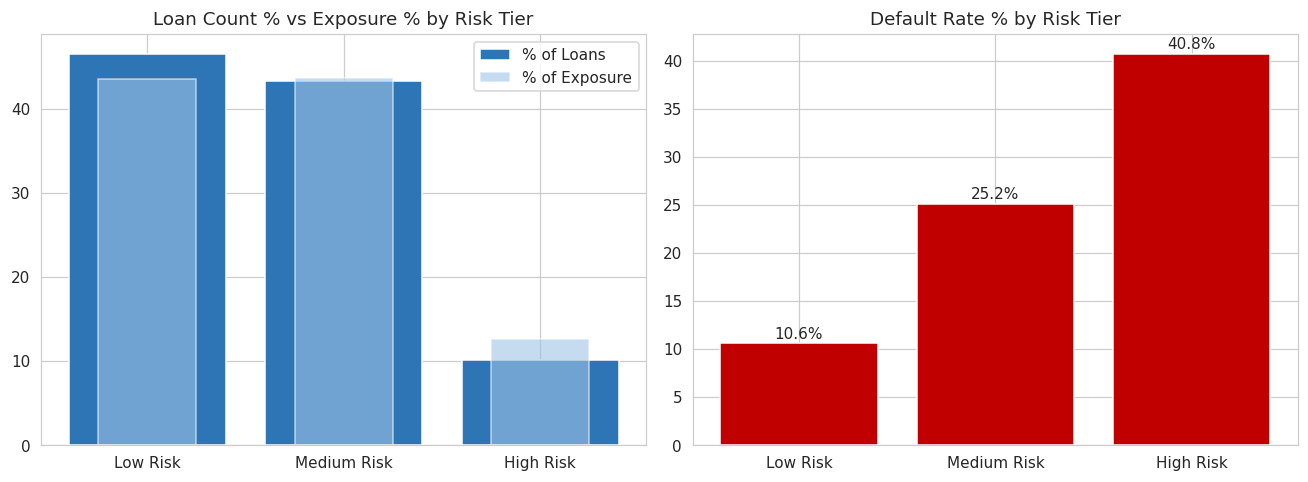

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ['Low Risk','Medium Risk','High Risk']
seg_plot = seg.reindex(order)

axes[0].bar(seg_plot.index, seg_plot['loan_pct'], color='#2E75B6', label='% of Loans')
axes[0].bar(seg_plot.index, seg_plot['exposure_pct'], color='#9DC3E6', alpha=0.6, label='% of Exposure', width=0.5)
axes[0].set_title('Loan Count % vs Exposure % by Risk Tier')
axes[0].legend()

axes[1].bar(seg_plot.index, seg_plot['default_rate_pct'], color='#C00000')
axes[1].set_title('Default Rate % by Risk Tier')
for i, v in enumerate(seg_plot['default_rate_pct']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## 11. Portfolio Analysis

In [19]:
portfolio_overall = pd.DataFrame({
    'Total Loans': [len(df)],
    'Resolved Loans': [df['is_resolved'].sum()],
    'Defaults': [df['is_default'].sum()],
    'Overall Default Rate %': [round(df['is_default'].sum()/df['is_resolved'].sum()*100, 2)],
    'Total Funded ($)': [df['funded_amnt'].sum()],
    'Avg Loan Amount ($)': [round(df['loan_amnt'].mean(), 0)],
    'Avg Interest Rate %': [round(df['int_rate'].mean(), 2)],
})
print(portfolio_overall.T)

                                   0
Total Loans             2.260668e+06
Resolved Loans          1.348099e+06
Defaults                2.693600e+05
Overall Default Rate %  1.998000e+01
Total Funded ($)        3.400421e+10
Avg Loan Amount ($)     1.504700e+04
Avg Interest Rate %     1.309000e+01


            total_loans  defaults  total_funded  default_rate_pct
issue_year                                                       
2007                603       158  4.791550e+06             26.20
2008               2393       496  1.997502e+07             20.73
2009               5281       723  5.181475e+07             13.69
2010              12537      1757  1.263512e+08             14.01
2011              21721      3297  2.573636e+08             15.18
2012              53367      8644  7.179427e+08             16.20
2013             134804     21024  1.982607e+09             15.60
2014             223103     41162  3.253489e+09             18.45
2015             375546     75804  5.498601e+09             20.19
2016             293105     68252  4.240361e+09             23.29
2017             169321     39169  2.421502e+09             23.13
2018              56318      8874  8.380769e+08             15.76


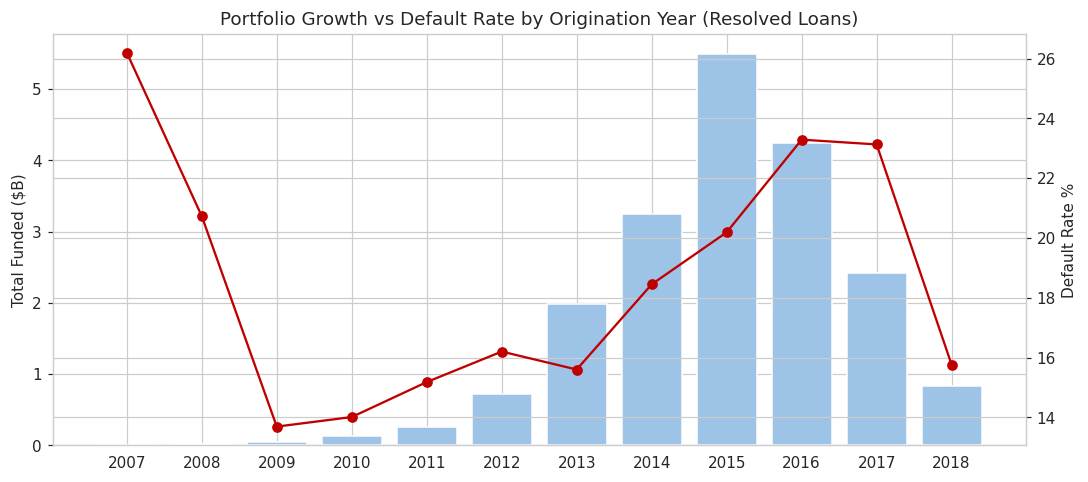

In [20]:
yearly = df[df['is_resolved']].groupby('issue_year').agg(
    total_loans=('id','count'),
    defaults=('is_default','sum'),
    total_funded=('funded_amnt','sum')
)
yearly['default_rate_pct'] = (yearly['defaults']/yearly['total_loans']*100).round(2)
print(yearly)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(yearly.index.astype(int).astype(str), yearly['total_funded']/1e9, color='#9DC3E6', label='Funded ($B)')
ax1.set_ylabel('Total Funded ($B)')
ax2 = ax1.twinx()
ax2.plot(yearly.index.astype(int).astype(str), yearly['default_rate_pct'], color='#C00000', marker='o', label='Default Rate %')
ax2.set_ylabel('Default Rate %')
ax1.set_title('Portfolio Growth vs Default Rate by Origination Year (Resolved Loans)')
plt.tight_layout()
plt.show()

## 12. Key Findings

1. **Overall default rate is 19.98%** on resolved loans (269,360 defaults out of 1,348,099
   resolved loans out of the full 2,260,668-loan portfolio). 59.6% of the portfolio is resolved;
   the remainder is Current/Late/Grace Period and excluded from the default-rate calculation.

2. **Grade is the strongest single risk driver observed.** Default rate rises almost
   monotonically from **6.04% (Grade A)** to **49.67% (Grade G)** — an 8x spread across the
   grade scale, confirming LendingClub's own risk grading is directionally sound.

3. **Loan term matters as much as grade.** 60-month loans default at **32.45%** vs **16.02%**
   for 36-month loans — roughly double, even before controlling for grade mix.

4. **DTI shows a clear, monotonic relationship with default**: 14.93% (DTI <10) rising to
   30.86% (DTI 40+). This is a genuine leading indicator, not just noise.

5. **Income band shows an inverse relationship with default**, but the spread is narrower than
   grade or term: 24.38% (<$30k) down to 15.62% ($120k+).

6. **Loan purpose reveals a hidden risk pocket**: `small_business` loans default at **29.86%** —
   the highest of any purpose — despite representing under 1% of loan volume. `debt_consolidation`
   (56% of volume) sits close to the portfolio average at 21.16%.

7. **Home ownership matters**: renters default at **23.23%** vs **17.23%** for borrowers with a
   mortgage — plausibly a proxy for financial stability rather than a direct cause.

8. **Employment length shows almost no relationship with default** (18.8%–20.6% across all
   tenure bands) — a genuinely useful negative finding: tenure alone is a weak risk signal in
   this dataset once other factors aren't controlled for.

9. **Risk segmentation validates cleanly**: the rule-based Low/Medium/High tiers (built purely
   from grade) show default rates of **10.64% / 25.18% / 40.80%** respectively. High Risk loans
   are only 10.1% of volume but 12.7% of dollar exposure and would account for a disproportionate
   share of defaults — a genuine risk-concentration signal.

10. **Portfolio default rate has trended upward with scale**: from ~14–16% in the 2010–2013
    origination vintages to **20–23%** in 2015–2017, before dropping in the small, still-largely-
    unresolved 2018 vintage (interpret 2018 with caution — many of those loans are still `Current`
    and haven't had time to default or pay off).

## 13. Business Recommendations

**Credit / Risk Team**
- Tighten underwriting on Grade E–G originations, or reprice them to better reflect the observed
  ~40–50% default rate.
- Treat 60-month term as an independent risk factor in pricing/approval, not just a proxy for
  grade — the volume-weighted gap (32.45% vs 16.02%) is too large to ignore.
- Add DTI-based overlays (e.g., extra scrutiny above DTI 30) given the clear monotonic
  relationship with default.

**Collections Team**
- Prioritize monitoring/outreach resources toward High Risk tier accounts (Grade E–G) — they're
  a small share of loan count (10.1%) but a disproportionate share of exposure (12.7%) and
  defaults.
- Build purpose-specific collection playbooks for `small_business` loans given their outsized
  29.86% default rate relative to volume.

**Portfolio Management**
- Monitor origination-year vintage performance actively — the 2015–2017 vintages show
  materially higher default rates (20–23%) than 2010–2013 (14–16%), which may reflect looser
  underwriting, portfolio growth outpacing risk controls, or macro conditions; worth a follow-up
  investigation.
- Track exposure-to-default-rate concentration by risk tier as an ongoing KPI, not a one-time
  analysis.

**Senior Management**
- Adopt Default Rate %, Portfolio Exposure by Risk Tier, and Vintage-Year Default Trend as
  standing dashboard KPIs (built out in the Power BI phase of this project).
- Treat the 2018 vintage default rate with caution in any board-level reporting — it's
  understated because most of those loans haven't resolved yet.

**Limitations (see also Section 5 Data Quality Audit)**
- Default-rate figures exclude unresolved loans (Current/Late/Grace Period, 40.4% of the
  portfolio) by design — this is a resolved-loan default rate, not a full-portfolio delinquency
  rate.
- `annual_inc` and `emp_title` are self-reported and not independently verified for all loans.
- Correlational findings (e.g., DTI, income, home ownership) are associations, not proven causal
  drivers — no causal inference is claimed anywhere in this notebook.
- This is single-lender (LendingClub), U.S.-only historical data; findings should not be assumed
  to generalize to other lenders or markets.